<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/NaiveBayes11thOct2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Naive Bayes Algorithm**
It is an algorithm designed for classification problem
* We look at all feature as independent
* We assume that each clue independently hints to the answer
* we combines those hints with the help of bayes rule to pick the most relaible class for it

it is used for email spam filter, sentiment analysis ('positive' or 'negative')

**There are three text models that we see in naive bayes**
* **Multinomial NB**: We uses word count here
    * When we have a bag of words and we have to use word count
* **Bernouli NB**: Uses word presence/absence
    * When we check the text is present or not
* **Gaussian NB**: For continuous featuers (number), we assume that it is a normal bell-curve likelihood
    * When the features are in number like Height, Age, Marks etc
* **Categorical NB**: It is used when features are categories, not numbers(new)
    * Predict whether a customer will buy based on (color or size)
    * Discrete features we calculate prob
    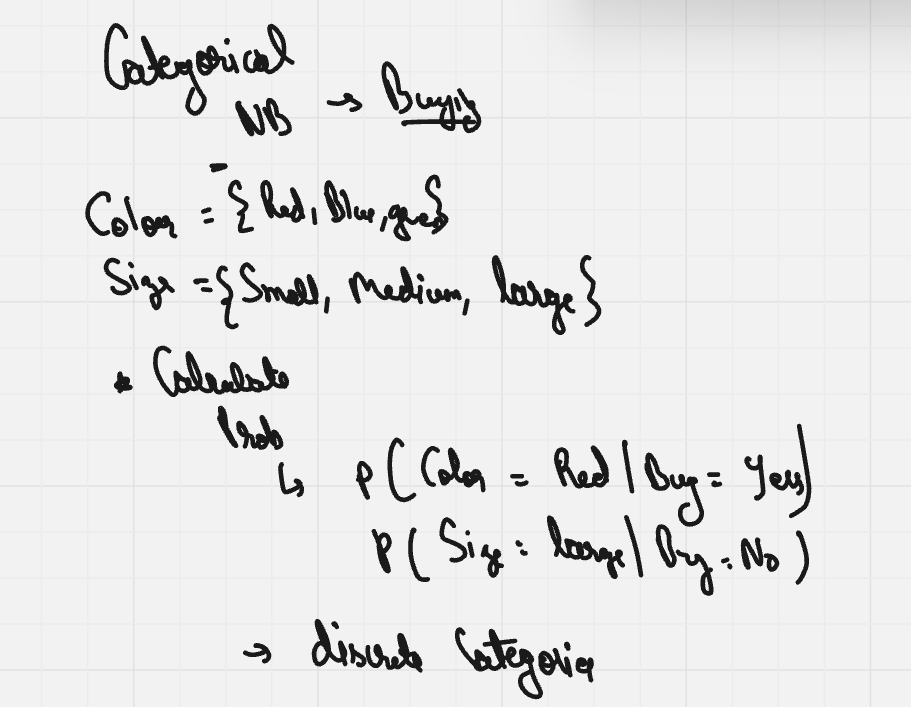

###**Example**
We will use 3 simple clues that we check whether it is present or not in mail
* win
* offer
* Meeting

We got 6 mails
###**Spam**
1. 'win a prize now' -> has win
2. 'limited time offer' -> has offer
3. 'exclusive offer just for you' -> has offer

###**Not Spam(HAM)**
1. 'Schedule a meeting tomorrow' -> has meeting
2. 'are we still on the meeting' -> has meeting
3. 'project meeting notes' -> has meeting

Counts by the class
* in Spam(3 mails) : win: 1, Offer: 2, meeting = 0
* in not Spam(3 mails): win = 0, offer = 0, meeting = 3

**let's say --> new mail arrived**
* `win meeting` -> (win = 1, offer = 0, meeting = 1)

In [ ]:
0.5 * 0.333 * 0.5 * 0.167

0.013902750000000002

In [ ]:
0.5 * 0.167 * 0.833 * 0.667

0.04639351850000001

Miro link for handwritten notes -> https://miro.com/app/board/uXjVJ7wAYu8=/?share_link_id=93578383155

**Python Implementation**

Dataset Link: https://drive.google.com/file/d/1bpUZT9E9jm9Wdo0h7rQbbjOvmiOtF4Jj/view?usp=sharing

**importing libraries**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.metrics import *
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('/content/nasa.csv', na_values=['?',' ','N/A'])

In [ ]:
df.shape

(4687, 40)

In [ ]:
df.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   object 
 12  Epoch Date Close Approach     4687 non-null   int64  
 13  Rel

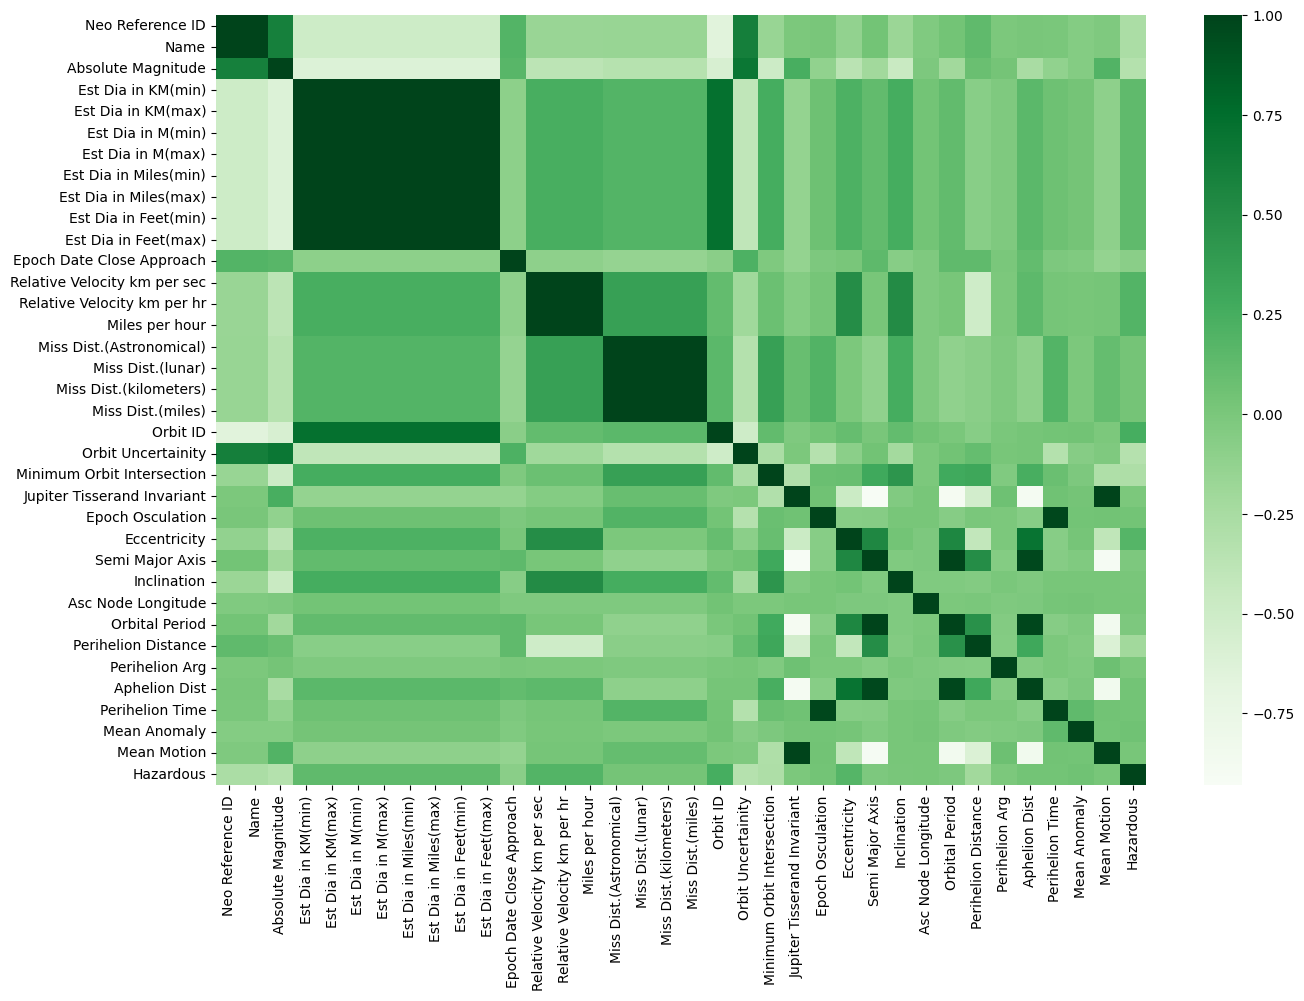

In [ ]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(numeric_only=True), cmap = 'Greens')
plt.show()

With respect to the correlation map, we can drop the columns that are having multicollinearity issue

In [ ]:
df.columns

Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body',
       'Orbit ID', 'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Equinox', 'Hazardous'],
      dtype='object')

In [ ]:
df = df.drop(['Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)','Miles per hour', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)','Orbit Determination Date','Close Approach Date','Neo Reference ID', 'Name'], axis =1)

In [ ]:
df.head()

,Absolute Magnitude,Est Dia in KM(min),Epoch Date Close Approach,Relative Velocity km per sec,Relative Velocity km per hr,Miss Dist.(Astronomical),Orbiting Body,Orbit ID,Orbit Uncertainity,Minimum Orbit Intersection,...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,21.6,0.127220,788947200000,6.115834,22017.003799,0.419483,Earth,17,5,0.025282,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,21.3,0.146068,788947200000,18.113985,65210.346095,0.383014,Earth,21,3,0.186935,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,20.3,0.231502,789552000000,7.590711,27326.560182,0.050956,Earth,22,0,0.043058,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,27.4,0.008801,790156800000,11.173874,40225.948191,0.285322,Earth,7,6,0.005512,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,21.6,0.127220,790156800000,9.840831,35426.991794,0.407832,Earth,25,1,0.034798,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [ ]:
encoder = LabelEncoder()
for x in df.columns:
  if df[x].dtype == 'object':
    df[x] = encoder.fit_transform(df[x])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Absolute Magnitude            4687 non-null   float64
 1   Est Dia in KM(min)            4687 non-null   float64
 2   Epoch Date Close Approach     4687 non-null   int64  
 3   Relative Velocity km per sec  4687 non-null   float64
 4   Relative Velocity km per hr   4687 non-null   float64
 5   Miss Dist.(Astronomical)      4687 non-null   float64
 6   Orbiting Body                 4687 non-null   int64  
 7   Orbit ID                      4687 non-null   int64  
 8   Orbit Uncertainity            4687 non-null   int64  
 9   Minimum Orbit Intersection    4687 non-null   float64
 10  Jupiter Tisserand Invariant   4687 non-null   float64
 11  Epoch Osculation              4687 non-null   float64
 12  Eccentricity                  4687 non-null   float64
 13  Sem

###**VIF**
As we are done with label encoding, now we are trying to check for multi colinearity between independent columns. VIF is one of the method of Feature selection which help us to choose the best column for our data with lowest colinearity

**Always remeber that the vif values should be less than 5 for a feature to be conisder**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                        Features     VIF_score
0             Absolute Magnitude  4.292549e+00
1             Est Dia in KM(min)  2.578505e+00
2      Epoch Date Close Approach  3.974209e+01
3   Relative Velocity km per sec           inf
4    Relative Velocity km per hr  2.905548e+14
5       Miss Dist.(Astronomical)  1.604793e+00
6                  Orbiting Body           NaN
7                       Orbit ID  2.725571e+00
8             Orbit Uncertainity  2.248295e+00
9     Minimum Orbit Intersection  2.142468e+00
10   Jupiter Tisserand Invariant  1.281014e+03
11              Epoch Osculation  2.630343e+01
12                  Eccentricity  1.898492e+01
13               Semi Major Axis  3.756130e+12
14                   Inclination  5.302672e+00
15            Asc Node Longitude  1.007827e+00
16                Orbital Period  1.036774e+03
17           Perihelion Distance  2.253352e+09
18                Perihelion Arg  1.012084e+00
19                 Aphelion Dist  1.528286e+10
20           

In [ ]:
df = df.drop('Equinox' ,axis = 1)

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                        Features     VIF_score
0             Absolute Magnitude  4.292549e+00
1             Est Dia in KM(min)  2.578505e+00
2      Epoch Date Close Approach  3.974209e+01
3   Relative Velocity km per sec           inf
4    Relative Velocity km per hr  2.905548e+14
5       Miss Dist.(Astronomical)  1.604793e+00
6                  Orbiting Body           NaN
7                       Orbit ID  2.725571e+00
8             Orbit Uncertainity  2.248295e+00
9     Minimum Orbit Intersection  2.142468e+00
10   Jupiter Tisserand Invariant  1.281014e+03
11              Epoch Osculation  2.630343e+01
12                  Eccentricity  1.898492e+01
13               Semi Major Axis  3.756130e+12
14                   Inclination  5.302672e+00
15            Asc Node Longitude  1.007827e+00
16                Orbital Period  1.036774e+03
17           Perihelion Distance  2.253351e+09
18                Perihelion Arg  1.012084e+00
19                 Aphelion Dist  1.528286e+10
20           

In [ ]:
df = df.drop('Orbiting Body' ,axis = 1)

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                        Features     VIF_score
0             Absolute Magnitude  4.292549e+00
1             Est Dia in KM(min)  2.578505e+00
2      Epoch Date Close Approach  3.974209e+01
3   Relative Velocity km per sec           inf
4    Relative Velocity km per hr  6.424536e+12
5       Miss Dist.(Astronomical)  1.604793e+00
6                       Orbit ID  2.725570e+00
7             Orbit Uncertainity  2.248295e+00
8     Minimum Orbit Intersection  2.142468e+00
9    Jupiter Tisserand Invariant  1.281026e+03
10              Epoch Osculation  2.630343e+01
11                  Eccentricity  1.898492e+01
12               Semi Major Axis  4.511721e+11
13                   Inclination  5.302672e+00
14            Asc Node Longitude  1.007827e+00
15                Orbital Period  1.036774e+03
16           Perihelion Distance  7.757620e+08
17                Perihelion Arg  1.012084e+00
18                 Aphelion Dist  6.721790e+13
19               Perihelion Time  2.767632e+01
20           

In [ ]:
df = df.drop(['Relative Velocity km per sec'], axis = 1)

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                       Features     VIF_score
0            Absolute Magnitude  4.292549e+00
1            Est Dia in KM(min)  2.578505e+00
2     Epoch Date Close Approach  3.974209e+01
3   Relative Velocity km per hr  3.416687e+00
4      Miss Dist.(Astronomical)  1.604793e+00
5                      Orbit ID  2.725569e+00
6            Orbit Uncertainity  2.248295e+00
7    Minimum Orbit Intersection  2.142468e+00
8   Jupiter Tisserand Invariant  1.281025e+03
9              Epoch Osculation  2.630343e+01
10                 Eccentricity  1.898492e+01
11              Semi Major Axis  7.086703e+12
12                  Inclination  5.302672e+00
13           Asc Node Longitude  1.007827e+00
14               Orbital Period  1.036774e+03
15          Perihelion Distance  1.135533e+09
16               Perihelion Arg  1.012084e+00
17                Aphelion Dist  2.681456e+10
18              Perihelion Time  2.767632e+01
19                 Mean Anomaly  1.236231e+00
20                  Mean Motion  7

In [ ]:
df = df.drop('Semi Major Axis' ,axis = 1)

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                       Features    VIF_score
0            Absolute Magnitude     4.292549
1            Est Dia in KM(min)     2.578505
2     Epoch Date Close Approach    39.742088
3   Relative Velocity km per hr     3.416687
4      Miss Dist.(Astronomical)     1.604793
5                      Orbit ID     2.725570
6            Orbit Uncertainity     2.248295
7    Minimum Orbit Intersection     2.142468
8   Jupiter Tisserand Invariant  1281.024320
9              Epoch Osculation    26.303426
10                 Eccentricity    18.984924
11                  Inclination     5.302672
12           Asc Node Longitude     1.007827
13               Orbital Period  1036.774209
14          Perihelion Distance    59.406539
15               Perihelion Arg     1.012084
16                Aphelion Dist  1549.684502
17              Perihelion Time    27.676322
18                 Mean Anomaly     1.236231
19                  Mean Motion   795.842299


In [ ]:
df = df.drop('Aphelion Dist' ,axis = 1)

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                       Features   VIF_score
0            Absolute Magnitude    4.249545
1            Est Dia in KM(min)    2.576993
2     Epoch Date Close Approach   39.741802
3   Relative Velocity km per hr    3.400966
4      Miss Dist.(Astronomical)    1.603976
5                      Orbit ID    2.718677
6            Orbit Uncertainity    2.237393
7    Minimum Orbit Intersection    2.132416
8   Jupiter Tisserand Invariant  721.261165
9              Epoch Osculation   26.291775
10                 Eccentricity   15.106828
11                  Inclination    3.769608
12           Asc Node Longitude    1.007688
13               Orbital Period   18.226474
14          Perihelion Distance   16.911766
15               Perihelion Arg    1.011050
16              Perihelion Time   27.671815
17                 Mean Anomaly    1.236163
18                  Mean Motion  578.703267


In [ ]:
df = df.drop('Jupiter Tisserand Invariant' ,axis = 1)

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                       Features  VIF_score
0            Absolute Magnitude   4.224356
1            Est Dia in KM(min)   2.550608
2     Epoch Date Close Approach  39.657846
3   Relative Velocity km per hr   3.199386
4      Miss Dist.(Astronomical)   1.575837
5                      Orbit ID   2.711391
6            Orbit Uncertainity   2.227388
7    Minimum Orbit Intersection   2.132403
8              Epoch Osculation  26.267103
9                  Eccentricity  13.556839
10                  Inclination   2.381781
11           Asc Node Longitude   1.007269
12               Orbital Period   8.788653
13          Perihelion Distance  16.587291
14               Perihelion Arg   1.010300
15              Perihelion Time  27.653544
16                 Mean Anomaly   1.236144
17                  Mean Motion   8.076923


In [ ]:
df = df.drop('Epoch Date Close Approach' ,axis = 1)

In [ ]:
# we dont have to drop the target
x = df.drop('Hazardous', axis = 1)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF_score'] = [vif(x.values , i) for i in range(x.shape[1])]

print(vif_data)

                       Features     VIF_score
0            Absolute Magnitude  2.532952e+02
1            Est Dia in KM(min)  3.329438e+00
2   Relative Velocity km per hr  1.493020e+01
3      Miss Dist.(Astronomical)  6.453285e+00
4                      Orbit ID  4.171592e+00
5            Orbit Uncertainity  5.083337e+00
6    Minimum Orbit Intersection  3.900923e+00
7              Epoch Osculation  1.873761e+08
8                  Eccentricity  7.450804e+01
9                   Inclination  5.935713e+00
10           Asc Node Longitude  3.805608e+00
11               Orbital Period  3.458341e+01
12          Perihelion Distance  2.039147e+02
13               Perihelion Arg  4.200858e+00
14              Perihelion Time  1.873954e+08
15                 Mean Anomaly  4.747312e+00
16                  Mean Motion  4.550119e+01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Absolute Magnitude           4687 non-null   float64
 1   Est Dia in KM(min)           4687 non-null   float64
 2   Relative Velocity km per hr  4687 non-null   float64
 3   Miss Dist.(Astronomical)     4687 non-null   float64
 4   Orbit ID                     4687 non-null   int64  
 5   Orbit Uncertainity           4687 non-null   int64  
 6   Minimum Orbit Intersection   4687 non-null   float64
 7   Epoch Osculation             4687 non-null   float64
 8   Eccentricity                 4687 non-null   float64
 9   Inclination                  4687 non-null   float64
 10  Asc Node Longitude           4687 non-null   float64
 11  Orbital Period               4687 non-null   float64
 12  Perihelion Distance          4687 non-null   float64
 13  Perihelion Arg    

**Model Building and Evaluation**

In [ ]:
x = df.drop('Hazardous', axis = 1)

In [ ]:
y = df['Hazardous']

In [ ]:
x

,Absolute Magnitude,Est Dia in KM(min),Relative Velocity km per hr,Miss Dist.(Astronomical),Orbit ID,Orbit Uncertainity,Minimum Orbit Intersection,Epoch Osculation,Eccentricity,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Perihelion Time,Mean Anomaly,Mean Motion
0,21.600,0.127220,22017.003799,0.419483,17,5,0.025282,2458000.5,0.425549,6.025981,314.373913,609.599786,0.808259,57.257470,2.458162e+06,264.837533,0.590551
1,21.300,0.146068,65210.346095,0.383014,21,3,0.186935,2458000.5,0.351674,28.412996,136.717242,425.869294,0.718200,313.091975,2.457795e+06,173.741112,0.845330
2,20.300,0.231502,27326.560182,0.050956,22,0,0.043058,2458000.5,0.348248,4.237961,259.475979,643.580228,0.950791,248.415038,2.458120e+06,292.893654,0.559371
3,27.400,0.008801,40225.948191,0.285322,7,6,0.005512,2458000.5,0.216578,7.905894,57.173266,514.082140,0.983902,18.707701,2.457902e+06,68.741007,0.700277
4,21.600,0.127220,35426.991794,0.407832,25,1,0.034798,2458000.5,0.210448,16.793382,84.629307,495.597821,0.967687,158.263596,2.457814e+06,135.142133,0.726395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4682,23.900,0.044112,79755.354273,0.041361,4,8,0.019777,2457637.5,0.361512,39.880491,164.183305,457.179984,0.741558,276.395697,2.457708e+06,304.306025,0.787436
4683,28.200,0.006089,11610.539577,0.006469,2,6,0.006451,2458000.5,0.073200,5.360249,345.225230,407.185767,0.996434,42.111064,2.458088e+06,282.978786,0.884117
4684,22.700,0.076658,25889.910626,0.061009,17,6,0.059972,2458000.5,0.368055,4.405467,37.026468,690.054279,0.965760,274.692712,2.458300e+06,203.501147,0.521698
4685,21.800,0.116026,40867.522309,0.260760,6,5,0.177510,2458000.5,0.202565,21.080244,163.802910,662.048343,1.185467,180.346090,2.458288e+06,203.524965,0.543767


In [ ]:
y

,Hazardous
0,True
1,False
2,True
3,False
4,True
...,...
4682,False
4683,False
4684,False
4685,False


**Data splitting**

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state= 42)

In [ ]:
model = GaussianNB()
model.fit(x_train,y_train)

GaussianNB()

In [ ]:
pred = model.predict(x_test)

In [ ]:
pred

array([False, False, False, ..., False, False, False])

In [ ]:
y_test

,Hazardous
3804,True
4680,False
805,True
3996,False
3523,False
...,...
4528,False
2487,False
2377,False
817,False


**Evaluate**

In [ ]:
print(f'Accuracy: {accuracy_score(y_test,pred)}')

Accuracy: 0.7380546075085325


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

       False       0.91      0.77      0.83       990
        True       0.31      0.56      0.40       182

    accuracy                           0.74      1172
   macro avg       0.61      0.67      0.62      1172
weighted avg       0.81      0.74      0.77      1172



**Logistic Regresion**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logModel = LogisticRegression()
logModel.fit(x_train,y_train)

LogisticRegression()

In [ ]:
logPred = logModel.predict(x_test)

In [ ]:
print(f'Accuracy: {accuracy_score(y_test,logPred)}')

Accuracy: 0.841296928327645


In [ ]:
print(classification_report(y_test,logPred))

              precision    recall  f1-score   support

       False       0.85      0.99      0.91       990
        True       0.42      0.05      0.10       182

    accuracy                           0.84      1172
   macro avg       0.63      0.52      0.51      1172
weighted avg       0.78      0.84      0.79      1172

